**Neural networks for road segmentation**
========================

Your next task is to train neural network to segment road on images from car cams.

The original dataset is provided by Karlsruhe Institute of Technology (http://www.cvlibs.net/datasets/kitti/eval_road.php). Their images are ±370x1270, but, for simlictiy, we will use 370x370 squares.

One can download the dataset from https://disk.yandex.ru/d/QPOw4hk84-se_w

Here is an example of input data with corresponding ground truth:

In [2]:
import os
import cv2
import numpy as np

import torchvision.transforms as transforms
from torch.utils.data import Dataset

import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
import albumentations as A
from albumentations.pytorch import ToTensorV2
import torch

def get_paths(path):
    _, _, filenames = next(os.walk(path))
    images_paths = []
    for filename in sorted(filenames):            
        images_paths.append(os.path.join(path, filename))
    return np.stack(images_paths)

class RoadDataset(Dataset):
    def __init__(self, images, masks, transform=None):
        self.images = sorted(images)
        self.masks = sorted(masks)
        self.transform = transform
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):        
        im_name = self.images[idx]
        mask_name = self.masks[idx]
        
        image = cv2.imread(im_name)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_name, cv2.IMREAD_GRAYSCALE)
        mask = (mask > 0).astype(np.float32)
        
        if self.transform:
            transformed = self.transform(image=image, mask=mask)
            image = transformed['image']
            mask = transformed['mask']
        else:
            image = torch.from_numpy(image.transpose(2, 0, 1)).float() / 255.0
            mask = torch.from_numpy(mask).float().unsqueeze(0)
        
        return {'image' : image, 'mask': mask}


In [4]:
X_train = get_paths("data/train/images")
y_train = get_paths("data/train/gt")

transform_train = A.Compose([
    A.PadIfNeeded(512, 512),
    A.RandomRotate90(p=0.5),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

transform_test = A.Compose([
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

In [5]:
train_dataset = RoadDataset(X_train, y_train, transform_train)
test_dataset = RoadDataset(X_train, y_train, transform_test)

In [6]:
def denormalize(tensor, mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)):
    mean = torch.tensor(mean).view(-1, 1, 1)
    std = torch.tensor(std).view(-1, 1, 1)
    tensor = tensor * std + mean
    tensor = torch.clamp(tensor, 0, 1)
    return tensor

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6399999].


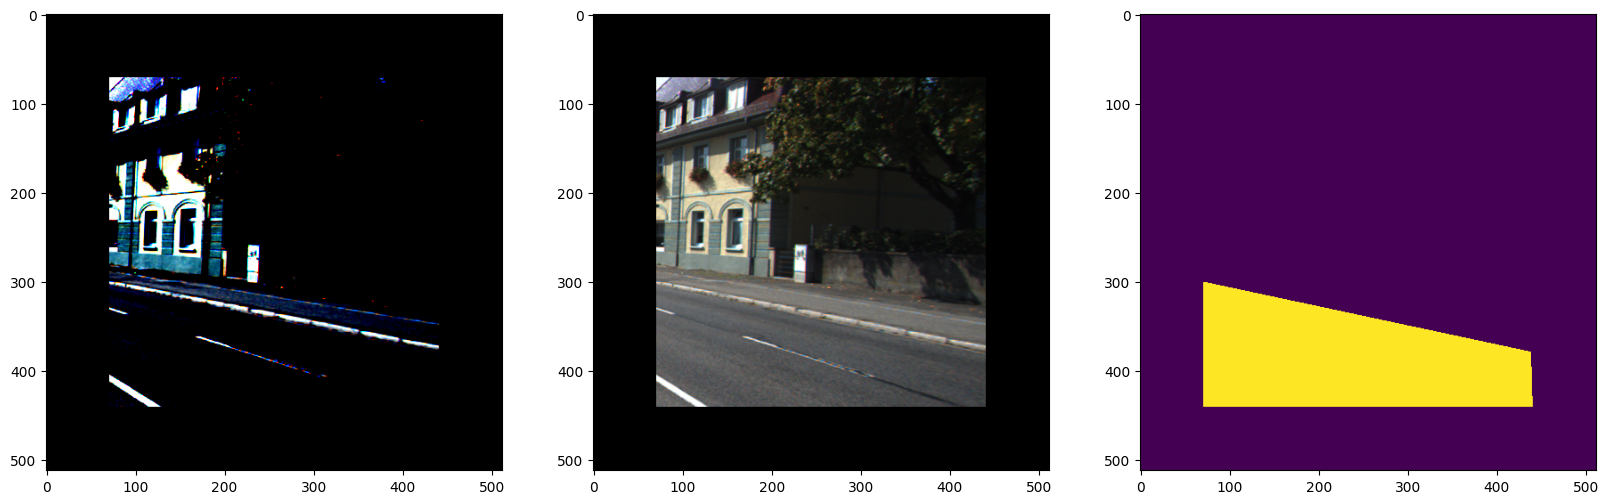

In [7]:
sample = train_dataset[110]
image = sample['image']
image_original = denormalize(sample['image'])
mask = sample['mask']

plt.figure(figsize=(20, 8))
plt.subplot(1, 3, 1)
plt.imshow(image.permute(1, 2, 0))
plt.subplot(1, 3, 2)
plt.imshow(image_original.permute(1, 2, 0))
plt.subplot(1, 3, 3)
plt.imshow(mask)

Workflow:
---
* Choose correct loss function, write training loop and code for testing. Feel free to use previous HW for inspiration. 
* Train any segmentation neural network from scratch (for example U-Net) and achieve >= 0.75 IoU on test set (40% points). See function to calculate the metric below.
* Use any pretrained model for image classification, convert it for segmentation by adding decoder (don't forget skip-connections) or usign dilated convolutions and achieve >= 0.87 IoU  on test set (60% points).

You're not allowed to do only one thing: train your network on test set.

----
Your final solution will consist of an ipython notebook with code (for final networks training + any experiments with data) and test metric calculation.

Feel free to ask in Telegram chat if something is not clear :3


In [8]:
print(f"Dataset length {len(train_dataset)}")

Dataset length 648


Dataset is small so actively use data augmentation: rotations, flip, color-change etc. to prevent overfitting.

Most likely you'll have to pad your images to 512x512 (it divides by 2^5=32, like U-Net wants). Use PadIfNeeded from Albumentations and central crop (see below) after prediction to calculate loss/metrics (you don't want to pay attention on padded values).

----
There is a hard data class imbalance in dataset, so the network output will be biased toward "zero" class. You can either tune the minimal probability threshold for the "road" class, or add class weights in optimized loss. You also can try to use softIoU or DICE loss.

Good luck!

In [9]:
def calc_iou(prediction, ground_truth):
    n_images = len(prediction)
    intersection, union = 0, 0
    for i in range(n_images):
        intersection += np.logical_and(prediction[i] > 0, ground_truth[i] > 0).astype(np.float32).sum() 
        union += np.logical_or(prediction[i] > 0, ground_truth[i] > 0).astype(np.float32).sum()
    return float(intersection) / union

In [10]:
def central_crop(images, size):
    current_size = images.size(2)
    border_len = (current_size - size) // 2
    images = images[:, :, border_len:current_size-border_len, border_len:current_size-border_len]

In [11]:
from typing import Tuple

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
import torch
import torch.nn as nn
from abc import ABC, abstractmethod
device = 'cuda:5' if torch.cuda.is_available() else 'cpu'

In [ ]:
class BaseSegmentationModel(nn.Module, ABC):
    @abstractmethod
    def forward(self, x):
        pass
    
    @abstractmethod
    def compute_loss(self, output, target):
        pass
    
    @abstractmethod
    def postprocess(self, output):
        pass


__all__ = ["UNetResNet50", "UNetResNet50RGB"]


class UNetResNet50(BaseSegmentationModel):
    """Standard UNet decoder on top of a ResNet-50 encoder."""

    def __init__(self, num_classes: int, pretrained: bool = True) -> None:
        super().__init__()

        self.num_classes = num_classes
        self.criterion = nn.CrossEntropyLoss()

        resnet = models.resnet50(pretrained=pretrained)

        self.encoder1 = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu)
        self.encoder2 = nn.Sequential(resnet.maxpool, resnet.layer1)
        self.encoder3 = resnet.layer2
        self.encoder4 = resnet.layer3
        self.encoder5 = resnet.layer4

        self.bridge = nn.Sequential(
            nn.Conv2d(2048, 2048, kernel_size=3, padding=1),
            nn.BatchNorm2d(2048),
            nn.ReLU(inplace=True),
        )

        self.up1 = nn.ConvTranspose2d(2048, 1024, kernel_size=2, stride=2)
        self.dec1 = self._make_decoder_block(2048, 1024)

        self.up2 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec2 = self._make_decoder_block(1024, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = self._make_decoder_block(512, 256)

        self.up4 = nn.ConvTranspose2d(256, 64, kernel_size=2, stride=2)
        self.dec4 = self._make_decoder_block(128, 64)

        self.up5 = nn.ConvTranspose2d(64, 64, kernel_size=2, stride=2)
        self.dec5 = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
        )

        self.final = nn.Conv2d(64, num_classes, kernel_size=1)

    @staticmethod
    def _make_decoder_block(in_channels: int, out_channels: int) -> nn.Sequential:
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    @staticmethod
    def _match_size(x: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        if x.shape[2:] != target.shape[2:]:
            x = F.interpolate(x, size=target.shape[2:], mode="bilinear", align_corners=False)
        return x

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        input_size: Tuple[int, int] = x.shape[2:]

        enc1 = self.encoder1(x)
        enc2 = self.encoder2(enc1)
        enc3 = self.encoder3(enc2)
        enc4 = self.encoder4(enc3)
        enc5 = self.encoder5(enc4)

        bridge = self.bridge(enc5)

        dec1 = self.up1(bridge)
        dec1 = self._match_size(dec1, enc4)
        dec1 = torch.cat([dec1, enc4], dim=1)
        dec1 = self.dec1(dec1)

        dec2 = self.up2(dec1)
        dec2 = self._match_size(dec2, enc3)
        dec2 = torch.cat([dec2, enc3], dim=1)
        dec2 = self.dec2(dec2)

        dec3 = self.up3(dec2)
        dec3 = self._match_size(dec3, enc2)
        dec3 = torch.cat([dec3, enc2], dim=1)
        dec3 = self.dec3(dec3)

        dec4 = self.up4(dec3)
        dec4 = self._match_size(dec4, enc1)
        dec4 = torch.cat([dec4, enc1], dim=1)
        dec4 = self.dec4(dec4)

        dec5 = self.up5(dec4)
        dec5 = self.dec5(dec5)

        output = self.final(dec5)
        output = F.interpolate(output, size=input_size, mode="bilinear", align_corners=False)

        return output

    def compute_loss(self, output: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        return self.criterion(output, target)

    def postprocess(self, output: torch.Tensor) -> torch.Tensor:
        return torch.argmax(output, dim=1)



In [13]:
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from torch.amp import autocast, GradScaler

def train(model, optimizer, criterion, train_dataloader, test_dataloader, num_epochs):
    train_losses = []
    test_losses = []
    scaler = GradScaler()
    
    plt.ion()
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    for epoch in range(num_epochs):
        model.train()
        epoch_train_loss = 0
        for batch in tqdm(train_dataloader, leave=False):
            images = batch['image'].to(device)
            target_masks = batch['mask'].to(device)
            
            with autocast('cuda', dtype=torch.bfloat16):
                pred_masks = model(images)
                central_crop(pred_masks, 512)
                loss = criterion(pred_masks, target_masks)
            
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()
            
            epoch_train_loss += loss.item()
        train_losses.append(epoch_train_loss / len(train_dataloader))

        model.eval()
        epoch_test_loss = 0
        with torch.no_grad():
            for batch in tqdm(test_dataloader, leave=False):
                images = batch['image'].to(device)
                target_masks = batch['mask'].to(device)
                
                with autocast('cuda', dtype=torch.bfloat16):
                    pred_masks = model(images)
                    central_crop(pred_masks, 512)
                    loss = criterion(pred_masks, target_masks)
                
                epoch_test_loss += loss.item()
        test_losses.append(epoch_test_loss / len(test_dataloader))

        model.eval()
        with torch.no_grad():
            test_batch = next(iter(test_dataloader))
            test_image = test_batch['image'][0].to(device)
            test_mask = test_batch['mask'][0].to(device)
            
            with autocast('cuda', dtype=torch.bfloat16):
                pred_mask = model(test_image.unsqueeze(0))
                pred_mask = torch.sigmoid(pred_mask) > 0.5

        axes[0,0].clear()
        axes[0,0].plot(train_losses, label='Train')
        axes[0,0].plot(test_losses, label='Test')
        axes[0,0].legend()
        axes[0,0].set_title('Loss')

        axes[0,1].clear()
        axes[0,1].imshow(denormalize(test_image.cpu()).permute(1,2,0))
        axes[0,1].set_title('Original Image')
        axes[0,1].axis('off')

        axes[0,2].clear()
        axes[0,2].imshow(test_mask.cpu().squeeze(), cmap='gray')
        axes[0,2].set_title('True Mask')
        axes[0,2].axis('off')

        axes[1,0].clear()
        axes[1,0].imshow(pred_mask.cpu().squeeze(), cmap='gray')
        axes[1,0].set_title('Predicted Mask')
        axes[1,0].axis('off')

        plt.tight_layout()
        plt.pause(0.1)
    
    plt.ioff()
    plt.show()
    
    return train_losses, test_losses

/home/korenikil/deep_vision_and_graphics/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [14]:
import torch
import torch.nn as nn

class IoULoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth
    
    def forward(self, pred, target):
        pred = torch.sigmoid(pred)
        
        intersection = (pred * target).sum()
        union = pred.sum() + target.sum() - intersection
        
        iou = (intersection + self.smooth) / (union + self.smooth)
        return 1 - iou


/home/korenikil/deep_vision_and_graphics/.venv/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/korenikil/deep_vision_and_graphics/.venv/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


RuntimeError: Given groups=1, weight of size [2048, 2048, 3, 3], expected input[8, 512, 16, 16] to have 2048 channels, but got 512 channels instead

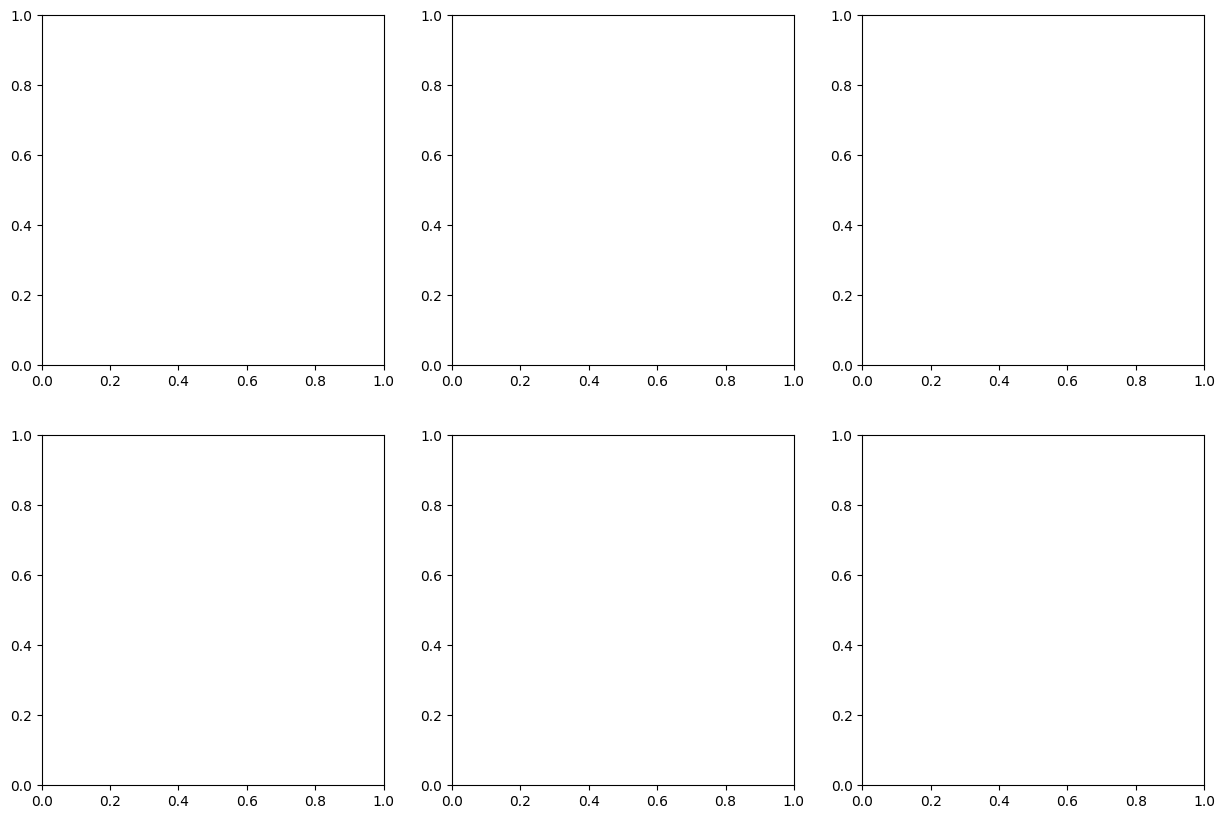

In [15]:
device = 'cuda:5'
model = UNetResNet50(num_classes=1, pretrained=False).to(device)
optimizer = torch.optim.Adam(model.parameters())
criterion = IoULoss()
BATCH_SIZE = 8


from torch.utils.data.dataloader import DataLoader

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True)
train_losses, test_losses = train(model, optimizer, criterion, train_loader, test_loader, num_epochs=50)